In [2]:
%%capture
%pip install tensorflow==2.16.2
%pip install pandas
%pip install scikit-learn

In [3]:
import tensorflow as tf 
import numpy as np 
from tensorflow.keras.layers import TextVectorization 
from tensorflow.keras.utils import get_file 

In [4]:
# Load the dataset 
path_to_file = get_file('shakespeare.txt', 'https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt') 
text = open(path_to_file, 'rb').read().decode(encoding='utf-8') 

# Preview the dataset 
print(text[:1000]) 

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak this in hunger for bread, not in thirst for revenge.



In [5]:
# Preprocess the dataset 
vocab_size = 10000  # Define o tamanho máximo do vocabulário (quantas palavras únicas serão consideradas)

seq_length = 100  # Define o tamanho máximo das sequências (não usado ainda aqui, mas será importante depois)

# Adapt TextVectorization to full text 
vectorizer = TextVectorization(max_tokens=vocab_size, output_mode='int')  
# Cria um objeto que transforma texto em números (tokens), limitando ao vocabulário de 10k palavras

text_ds = tf.data.Dataset.from_tensor_slices([text]).batch(1)  
# Cria um dataset do TensorFlow com o texto (colocado em lista) e divide em batches de tamanho 1

vectorizer.adapt(text_ds)  
# "Treina" o vectorizer: ele aprende quais são as palavras mais frequentes no texto

# Vectorize the text 
vectorized_text = vectorizer([text])[0]  
# Aplica a transformação: converte o texto em uma sequência de números (índices de palavras)

print("Vectorized text shape:", vectorized_text.shape)  
# Mostra o tamanho da sequência gerada

print("First 10 vectorized tokens:", vectorized_text.numpy()[:10])  
# Mostra os primeiros 10 números (tokens) do texto convertido

Vectorized text shape: (202646,)
First 10 vectorized tokens: [ 89 270 138  36 982 144 673 125  16 106]


2026-03-24 17:47:16.206839: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Create input and target sequences

In [6]:
def create_sequences(text, seq_length): 
    input_seqs = []  # Lista que vai guardar as sequências de entrada (inputs)
    target_seqs = []  # Lista que vai guardar as sequências alvo (labels)

    for i in range(len(text) - seq_length):  # Percorre o texto criando janelas deslizantes
        input_seq = text[i:i + seq_length]  # Pega uma sequência de tamanho fixo (input)
        target_seq = text[i + 1:i + seq_length + 1]  # Pega a mesma sequência deslocada em +1 (target)

        input_seqs.append(input_seq)  # Adiciona a sequência de entrada na lista
        target_seqs.append(target_seq)  # Adiciona a sequência alvo na lista

    return np.array(input_seqs), np.array(target_seqs)  # Converte listas em arrays numpy


# Generate sequences 
X, Y = create_sequences(vectorized_text.numpy(), seq_length)  
# Aplica a função no texto já vetorizado (transformado em números)


# Check if sequences are correctly generated 
print("Number of sequences generated:", len(X))  
# Mostra quantas sequências foram criadas

print("Sample input sequence:", X[0] if len(X) > 0 else "No sequences generated")  
# Mostra um exemplo de sequência de entrada


# Check if X and Y are not empty 
assert X.size > 0, "Input data X is empty"  
# Garante que X não está vazio (senão dá erro)

assert Y.size > 0, "Target data Y is empty"  
# Garante que Y não está vazio

X = tf.convert_to_tensor(X)  
# Converte X (numpy) para tensor do TensorFlow

Y = tf.convert_to_tensor(Y)  
# Converte Y (numpy) para tensor do TensorFlow

print("Shape of X:", X.shape)  
# Mostra o formato de X (quantas sequências, tamanho de cada uma)

print("Shape of Y:", Y.shape)  
# Mostra o formato de Y

Number of sequences generated: 202546
Sample input sequence: [  89  270  138   36  982  144  673  125   16  106   34  106  106   89
  270    7   41   34 1286  344    4  200   64    4 3690   34 1286 1286
   89  270   89    7   93 1187  225   12 2442  592    4    2  307   34
   36 2655   36 2655   89  270   72   79  506   27    3   56   24 1390
   57   40  161 2328  644    9 4980   34   32   54 2863  885   72   17
   18  163  146  146  165  270   74  218   46  595   89  270   36   41
 6739  172  595    2 1780   46   29 1323 5151   47   58 4151   79   39
   60   58]
Shape of X: (202546, 100)
Shape of Y: (202546, 100)


Build the Transformer model

In [7]:
from tensorflow.keras.layers import Embedding, MultiHeadAttention, Dense, LayerNormalization, Dropout
# Importa camadas essenciais do Transformer

from tensorflow.keras.models import Model
# Importa a base para criar o modelo

class TransformerBlock(tf.keras.layers.Layer):
    # Define um bloco Transformer (a unidade básica do modelo)

    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super(TransformerBlock, self).__init__()

        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        # Camada de atenção (o "cérebro" do Transformer)

        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation="relu"),
            Dense(embed_dim),
        ])
        # Rede feed-forward (processamento após atenção)

        self.layernorm1 = LayerNormalization(epsilon=1e-6)
        # Normalização após atenção

        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        # Normalização após feed-forward

        self.dropout1 = Dropout(rate)
        # Dropout após atenção

        self.dropout2 = Dropout(rate)
        # Dropout após feed-forward

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs)
        # Aplica self-attention (cada palavra olha para todas as outras)

        attn_output = self.dropout1(attn_output, training=training)
        # Aplica dropout na saída da atenção

        out1 = self.layernorm1(inputs + attn_output)
        # Residual connection + normalização

        ffn_output = self.ffn(out1)
        # Passa pela rede feed-forward

        ffn_output = self.dropout2(ffn_output, training=training)
        # Aplica dropout

        return self.layernorm2(out1 + ffn_output)
        # Residual connection + normalização final


class TransformerModel(Model):
    # Define o modelo completo Transformer

    def __init__(self, vocab_size, embed_dim, num_heads, ff_dim, num_layers, seq_length):
        super(TransformerModel, self).__init__()

        self.embedding = Embedding(vocab_size, embed_dim)
        # Converte tokens (números) em vetores densos

        self.pos_encoding = self.positional_encoding(seq_length, embed_dim)
        # Gera codificação posicional (ordem das palavras)

        self.transformer_blocks = [TransformerBlock(embed_dim, num_heads, ff_dim) for _ in range(num_layers)]
        # Cria vários blocos Transformer empilhados

        self.dense = Dense(vocab_size)
        # Camada final que prevê o próximo token

    def positional_encoding(self, seq_length, embed_dim):
        angle_rads = self.get_angles(
            np.arange(seq_length)[:, np.newaxis],
            np.arange(embed_dim)[np.newaxis, :],
            embed_dim
        )
        # Calcula ângulos para cada posição e dimensão

        angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
        # Aplica seno nas posições pares

        angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])
        # Aplica cosseno nas posições ímpares

        pos_encoding = angle_rads[np.newaxis, ...]
        # Adiciona dimensão de batch

        return tf.cast(pos_encoding, dtype=tf.float32)
        # Converte para tensor

    def get_angles(self, pos, i, embed_dim):
        angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(embed_dim))
        # Fórmula que define a frequência dos sinais

        return pos * angle_rates
        # Retorna os ângulos

    def call(self, inputs, training=False):
        seq_len = tf.shape(inputs)[1]
        # Pega o tamanho da sequência

        x = self.embedding(inputs)
        # Converte tokens em embeddings

        x += self.pos_encoding[:, :seq_len, :]
        # Soma a informação de posição aos embeddings

        for transformer_block in self.transformer_blocks:
            x = transformer_block(x, training=training)
            # Passa pelos blocos Transformer

        output = self.dense(x)
        # Gera logits para cada token possível

        return output
        # Retorna a saída do modelo

In [8]:
# Hyperparameters 
embed_dim = 256  # Dimensão dos embeddings (tamanho do vetor que representa cada palavra)

num_heads = 4  # Número de "cabeças" de atenção (quantas atenções em paralelo o modelo usa)

ff_dim = 512  # Tamanho da camada interna da rede feed-forward (FFN)

num_layers = 4  # Quantidade de blocos Transformer empilhados


# Build the Transformer model 
model = TransformerModel(vocab_size, embed_dim, num_heads, ff_dim, num_layers, seq_length)
# Cria o modelo Transformer com os hiperparâmetros definidos


# Provide input shape to build the model by passing a dummy input with maxval specified
_ = model(tf.random.uniform((1, seq_length), maxval=vocab_size, dtype=tf.int32))
# Passa um input fake (batch=1, tamanho da sequência) para "construir" o modelo internamente


# Compile the model 
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')
# Define como o modelo vai aprender (otimizador + função de erro)


# Summary of the model 
model.summary()
# Mostra a arquitetura completa do modelo (camadas, parâmetros, shapes)

Model: "transformer_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (1, 100, 256)          │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ ?                      │     1,315,840 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ ?                      │     1,315,840 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ ?                      │     1,315,840 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_3             │ ?                      │     1,315,840 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (1, 100, 10000)        │     2,570,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,393,360 (39.65 MB)

 Trainable params: 10,393,360 (39.65 MB)

 Non-trainable params: 0 (0.00 B)

Train the Transformer model

In [9]:
%pip install matplotlib


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [10]:
X = X[:10000]
Y = Y[:10000]

Epoch 1/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 326s 1s/step - loss: 10.7386
Epoch 2/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 328s 1s/step - loss: 10.8116


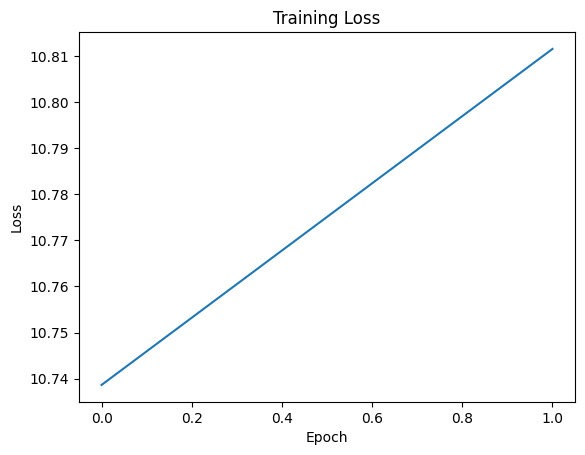

In [12]:
# Import necessary libraries for training visualization
import matplotlib.pyplot as plt  # Biblioteca para criar gráficos
from tensorflow.keras.callbacks import EarlyStopping  # Callback para parar o treino automaticamente

# Early stopping callback to stop training if the loss doesn't improve
early_stopping = EarlyStopping(monitor='loss', patience=2, restore_best_weights=True)
# Cria um mecanismo que para o treino se a loss não melhorar por 2 épocas seguidas
# restore_best_weights=True faz o modelo voltar para os melhores pesos encontrados

# Train the transformer model on the full input and target sequences
history = model.fit(X, Y, epochs=2, batch_size=32, callbacks=[early_stopping])
# Treina o modelo usando:
# X → entradas (sequências)
# Y → targets (próximos tokens)
# epochs=2 → número de vezes que o modelo vê todo o dataset
# batch_size=32 → quantas sequências são processadas por vez
# callbacks → inclui o early stopping

# Plot training loss to monitor model performance over epochs
plt.plot(history.history['loss'])  # Plota os valores da loss ao longo das épocas
plt.xlabel('Epoch')  # Nome do eixo X
plt.ylabel('Loss')  # Nome do eixo Y
plt.title('Training Loss')  # Título do gráfico
plt.show()  # Mostra o gráfico

 Generate text with the trained model

In [13]:
def generate_text(model, start_string, num_generate=100, temperature=1.0):
    # Convert the start string to a vectorized format
    input_eval = vectorizer([start_string]).numpy()  
    # Converte o texto inicial em tokens (números)

    # Ensure the input length is the same as the model's expected input shape
    if input_eval.shape[1] < seq_length:
        padding = np.zeros((1, seq_length - input_eval.shape[1]))  
        # Cria padding com zeros se o texto for menor que seq_length

        input_eval = np.concatenate((padding, input_eval), axis=1)  
        # Junta padding + texto

    elif input_eval.shape[1] > seq_length:
        input_eval = input_eval[:, -seq_length:]  
        # Corta o texto se for maior que seq_length

    input_eval = tf.convert_to_tensor(input_eval)  
    # Converte para tensor

    # Initialize an empty list to store generated text
    text_generated = []  
    # Lista para armazenar palavras geradas

    # Start generating text
    for i in range(num_generate):
        # Make predictions using the model
        predictions = model(input_eval)  
        # Modelo gera probabilidades para cada token

        # Remove only the batch dimension
        predictions = predictions[0]  
        # Remove dimensão do batch → fica (seq_length, vocab_size)

        # Apply temperature to predictions
        predictions = predictions / temperature  
        # Controla aleatoriedade

        # Use a categorical distribution to predict the next word
        predicted_id = tf.random.categorical(predictions, num_samples=1)[0, 0].numpy()  
        # Escolhe o próximo token baseado nas probabilidades

        # Update the input tensor
        input_eval = np.append(input_eval.numpy(), [[predicted_id]], axis=1)  
        # Adiciona o token gerado na sequência

        input_eval = input_eval[:, -seq_length:]  
        # Mantém apenas os últimos tokens (janela deslizante)

        input_eval = tf.convert_to_tensor(input_eval)  
        # Converte de volta para tensor

        # Append the predicted word
        text_generated.append(vectorizer.get_vocabulary()[predicted_id])  
        # Converte o índice de volta para palavra

    # Return the generated text
    return start_string + ' ' + ' '.join(text_generated)  
    # Junta tudo em uma string final


# Generate text with temperature control
start_string = "To be, or not to be"  
# Texto inicial (seed)

generated_text = generate_text(model, start_string, temperature=0.7)  
# Gera texto com menor aleatoriedade

print(generated_text)  
# Mostra o resultado

To be, or not to be logic drown cause says proud blemish unexamined sigeia pumps true rejourn instruments noble been chances let let noble name let unstaind fought horn scabs pedant call unseemly noble about virtuouswhere novice sistercousin noble muffle shouldst westward lead insinuate droop noble horn shippd scornful by virtue his oxlips her nuptials let staring minstrel noble spleen ignorance innocent betrothd noble mayest nothing passd thwack guards about wooer enjoyd noble of honour let dark scholar gasping meeting take noble practise follow renouncement being ill hungry wrenching staying noble soaring noble dragon coldly stinging cracks awry pitchy titus severing proud did unsatisfied complaints proofs


Exercise 1: Experiment with different sequence lengths

Objective: Implement different sequence lengths to understand their effect on the performance of the Transformer model.

Instructions:

Change the sequence length to 50

Preprocess the data set with the new sequence length

Train the model and compare the training loss

2026-03-24 21:15:42.534686: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Vectorized text shape: (202646,)
First 10 vectorized tokens: [ 89 270 138  36 982 144 673 125  16 106]
Number of sequences generated: 202596
Sample input sequence: [  89  270  138   36  982  144  673  125   16  106   34  106  106   89
  270    7   41   34 1286  344    4  200   64    4 3690   34 1286 1286
   89  270   89    7   93 1187  225   12 2442  592    4    2  307   34
   36 2655   36 2655   89  270   72   79]
Shape of X: (202596, 50)
Shape of Y: (202596, 50)


Model: "transformer_model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (1, 50, 256)           │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_4             │ ?                      │     1,315,840 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_5             │ ?                      │     1,315,840 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_6             │ ?                      │     1,315,840 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_7             │ ?                      │     1,315,840 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (1, 50, 10000)         │     2,570,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,393,360 (39.65 MB)

 Trainable params: 10,393,360 (39.65 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 217s 678ms/step - loss: 12.0928
Epoch 2/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 208s 664ms/step - loss: 11.9252


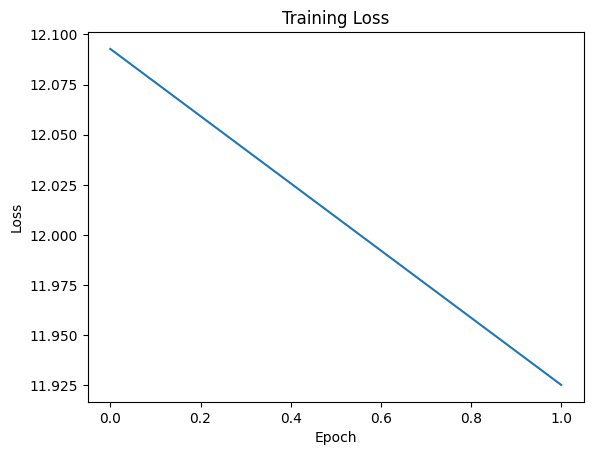

In [14]:
# Preprocess the dataset 
vocab_size = 10000 
seq_length = 50 

# Adapt TextVectorization to full text 
vectorizer = TextVectorization(max_tokens=vocab_size, output_mode='int') 
text_ds = tf.data.Dataset.from_tensor_slices([text]).batch(1) 
vectorizer.adapt(text_ds) 

# Vectorize the text 
vectorized_text = vectorizer([text])[0] 
print("Vectorized text shape:", vectorized_text.shape) 
print("First 10 vectorized tokens:", vectorized_text.numpy()[:10]) 

X, Y = create_sequences(vectorized_text.numpy(), seq_length) 


# Check if sequences are correctly generated 
print("Number of sequences generated:", len(X)) 
print("Sample input sequence:", X[0] if len(X) > 0 else "No sequences generated") 

# Check if X and Y are not empty 
assert X.size > 0, "Input data X is empty" 
assert Y.size > 0, "Target data Y is empty" 
X = tf.convert_to_tensor(X) 
Y = tf.convert_to_tensor(Y) 
print("Shape of X:", X.shape) 
print("Shape of Y:", Y.shape)
X = X[:10000]
Y = Y[:10000]
# Hyperparameters 
embed_dim = 256 
num_heads = 4 
ff_dim = 512 
num_layers = 4 

# Build the Transformer model 
model = TransformerModel(vocab_size, embed_dim, num_heads, ff_dim, num_layers, seq_length)

# Provide input shape to build the model by passing a dummy input with maxval specified
_ = model(tf.random.uniform((1, seq_length), maxval=vocab_size, dtype=tf.int32))

# Compile the model 
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy')

# Summary of the model 
model.summary()
# Early stopping callback to stop training if the loss doesn't improve
early_stopping = EarlyStopping(monitor='loss', patience=2, restore_best_weights=True)

# Train the transformer model on the full input and target sequences
history = model.fit(X, Y, epochs=2, batch_size=32, callbacks=[early_stopping])

# Plot training loss to monitor model performance over epochs
plt.plot(history.history['loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()

Exercise 2: Add a learning rate scheduler

Objective: Implement a learning rate scheduler to adjust the learning rate during training.

Instructions:

Define a learning rate scheduler that reduces the learning rate by half every 10 epochs

Train the model with the learning rate scheduler and compare the training loss


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Epoch 1/2
157/157 ━━━━━━━━━━━━━━━━━━━━ 200s 1s/step - loss: 11.9271 - learning_rate: 0.0010
Epoch 2/2
157/157 ━━━━━━━━━━━━━━━━━━━━ 193s 1s/step - loss: 11.8148 - learning_rate: 0.0010


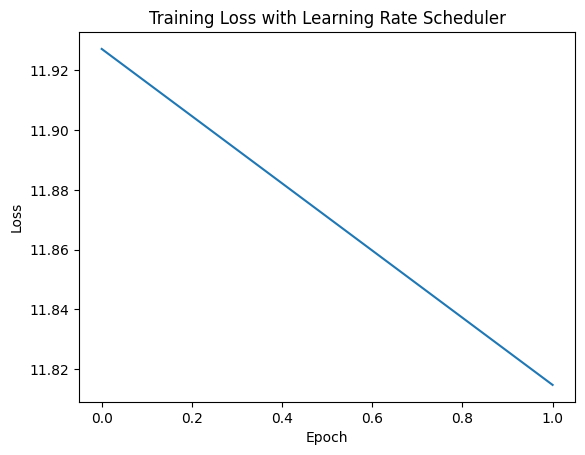

In [15]:
# Write your code here
%pip install pandas
%pip install scikit-learn
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Layer, Dense, LayerNormalization, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Define a learning rate scheduler  
def scheduler(epoch, lr):  
    if epoch % 10 == 0 and epoch != 0:  
        lr = lr * 0.5  
    return lr  
 

callback = tf.keras.callbacks.LearningRateScheduler(scheduler)  


# Train the model with the learning rate scheduler  
history = model.fit(X, Y, epochs=2, batch_size=64, callbacks=[callback])  
   

# Plot the training loss  
plt.plot(history.history['loss'])  
plt.xlabel('Epoch')  
plt.ylabel('Loss')  
plt.title('Training Loss with Learning Rate Scheduler')  
plt.show()

Exercise 3: Generate longer text sequences

Objective: To explore the model's text generation capabilities and generate longer sequences.

Instructions:

Modify the generate_text function to generate 200 tokens instead of 100

Generate text using the trained model and the modified function

In [16]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Layer, Dense, LayerNormalization, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

def generate_text(model, start_string, num_generate=200):
    # Convert the start string to numbers (vectorize)
    input_eval = vectorizer([start_string]).numpy()

    # Ensure the input tensor has the correct shape
    input_eval = tf.convert_to_tensor(input_eval[:, -5:])  # Ensure it has a shape of (1, 5)
    
    text_generated = []

    for i in range(num_generate):
        # Make predictions using the model
        predictions = model(input_eval)

        # Ensure predictions is a matrix with shape [batch_size, num_classes]
        predictions = tf.squeeze(predictions, 0)  # Remove the batch dimension
        predictions = tf.expand_dims(predictions, 0)  # Add back a batch dimension for categorical
        
        # Use a categorical distribution to predict the next word
        predicted_id = tf.random.categorical(predictions, num_samples=1)[-1, 0].numpy()

        # Update the input tensor to include the predicted word, maintaining the sequence length
        input_eval = np.append(input_eval.numpy(), [[predicted_id]], axis=1)  # Append predicted token
        input_eval = input_eval[:, -5:]  # Keep only the last 5 tokens to match input shape
        input_eval = tf.convert_to_tensor(input_eval)  # Convert back to tensor
        
        # Add the predicted word to the generated text
        text_generated.append(vectorizer.get_vocabulary()[predicted_id])

    return start_string + ' ' + ' '.join(text_generated)


# Generate longer text
start_string = "To be, or not to be"
generated_text = generate_text(model, start_string)

print(generated_text)

2026-03-24 21:37:29.596772: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: INVALID_ARGUMENT: logits should be a matrix, got shape [1,5,10000]


InvalidArgumentError: {{function_node __wrapped__Multinomial_device_/job:localhost/replica:0/task:0/device:CPU:0}} logits should be a matrix, got shape [1,5,10000] [Op:Multinomial] name: 